# TDCRPy — Functional Validation Notebook

Compares **two user-chosen versions** of TDCRPy on a fixed set of nuclides
using both the **analytical** and **stochastic** models at a fixed free parameter L.

| Nuclide | Decay mode | Key physics exercised |
|---------|------------|----------------------|
| H-3     | Pure β⁻ (18.6 keV) | Low-energy quenching, pure beta path |
| Fe-55   | EC + Mn Kα X-rays (5.9 keV) | Atomic relaxation, Auger electrons |
| Co-60   | β⁻ + γ (1.17 / 1.33 MeV) | Photon interactions, photoelectric / pair production |
| Sr-90   | Pure β⁻ (0.546 MeV) | Medium-energy beta quenching |
| Cd-109  | EC + Ag-109m IT γ (88 keV, delayed) | Delayed coincidences, Auger cascade |

> **Edit the *Configuration* cell below, then run all cells.**

## ⚙️ Configuration — edit here

In [25]:
# ─── Versions to compare ────────────────────────────────────────────────────
VERSION_REF = '2.20.3'   # reference / older version (installed in isolation)
VERSION_NEW = '2.20.12'   # new version to validate (must already be installed)

# ─── Physical parameters ────────────────────────────────────────────────────
L  = 9.0      # free parameter (keV⁻¹), fixed — no optimisation
kB = 1.0e-5   # Birks constant (cm keV⁻¹)
V  = 10       # scintillator volume (mL)
N  = 10000     # number of Monte-Carlo trials (stochastic model)
ne = 1000     # discretisation bins (analytical model)

# ─── Nuclides ───────────────────────────────────────────────────────────────
NUCLIDES = [
    'H-3',     # pure β⁻, 18.6 keV
    'Fe-55',   # EC + Mn Kα X-rays (5.9 keV) — Auger cascade
    'Co-60',   # β⁻ + 1.17/1.33 MeV γ — photoelectric / pair production
    'Sr-90',   # pure β⁻, 0.546 MeV
    'Cd-109',  # EC + delayed Ag-109m IT γ (88 keV)
]

# ─── Plotting ───────────────────────────────────────────────────────────────
COLORS = ['#1f77b4', '#e67e22', '#27ae60', '#e74c3c', '#8e44ad']

print(f'Comparing  {VERSION_REF}  vs  {VERSION_NEW}')
print(f'L={L} keV⁻¹ | kB={kB} cm keV⁻¹ | V={V} mL | N={N}')
print(f'Nuclides: {NUCLIDES}')

Comparing  2.20.3  vs  2.20.12
L=9.0 keV⁻¹ | kB=1e-05 cm keV⁻¹ | V=10 mL | N=10000
Nuclides: ['H-3', 'Fe-55', 'Co-60', 'Sr-90', 'Cd-109']


## 1. Setup

In [26]:
import sys, os, subprocess, json, tempfile, pathlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from importlib.metadata import version
warnings.filterwarnings('ignore')

# ── Install VERSION_NEW if not already present ────────────────────────────
try:
    installed = version('TDCRPy')
    if installed != VERSION_NEW:
        print(f'Upgrading TDCRPy {installed} → {VERSION_NEW} ...')
        subprocess.run([sys.executable, '-m', 'pip', 'install',
                        f'TDCRPy=={VERSION_NEW}', '-q'], check=True)
    else:
        print(f'TDCRPy {VERSION_NEW} already installed.')
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install',
                    f'TDCRPy=={VERSION_NEW}', '-q'], check=True)

import tdcrpy as td
import tdcrpy.TDCRPy as tm
print(f'Active TDCRPy : {version("TDCRPy")}  |  Python {sys.version.split()[0]}')

TDCRPy 2.20.12 already installed.
Active TDCRPy : 2.20.12  |  Python 3.13.14


In [27]:
# ── Install VERSION_REF in an isolated temp directory ─────────────────────
TMP_REF = pathlib.Path(tempfile.mkdtemp()) / f'tdcrpy_{VERSION_REF.replace(".","")}'
TMP_REF.mkdir(exist_ok=True)

print(f'Installing TDCRPy=={VERSION_REF} to isolated dir ...')
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     f'TDCRPy=={VERSION_REF}', '--target', str(TMP_REF), '-q', '--no-deps'],
    capture_output=True, text=True
)
print('  → OK' if r.returncode == 0 else f'  ERROR: {r.stderr[-200:]}')

def run_ref(script, timeout=600):
    """Execute *script* in a subprocess with VERSION_REF on PYTHONPATH."""
    env = os.environ.copy()
    env['PYTHONPATH'] = str(TMP_REF) + os.pathsep + env.get('PYTHONPATH', '')
    full = 'import warnings; warnings.filterwarnings("ignore")\n' + script
    r = subprocess.run([sys.executable, '-c', full],
                       capture_output=True, text=True, timeout=timeout, env=env)
    return r.stdout.strip(), r.stderr.strip()

ver_check, _ = run_ref('from importlib.metadata import version; print(version("TDCRPy"))')
print(f'Reference subprocess: TDCRPy {ver_check}')

Installing TDCRPy==2.20.3 to isolated dir ...
  → OK
Reference subprocess: TDCRPy 2.20.12


## 2. Script builders
Helper functions that produce Python source strings from the current parameters.

In [28]:
def make_analytical_script():
    """Return a Python script that runs modelAnalytical for all NUCLIDES."""
    return f"""
import json
import tdcrpy.TDCR_model_lib as tl
nuclides = {NUCLIDES!r}
results = {{}}
for rad in nuclides:
    try:
        s, d, t = tl.modelAnalytical({L}, 0, 0, 0, 0, rad, {kB}, {V}, 'eff', {ne})
        results[rad] = {{'eff_S': float(s), 'eff_D': float(d), 'eff_T': float(t)}}
    except Exception as e:
        results[rad] = {{'error': type(e).__name__, 'msg': str(e)[:120]}}
print(json.dumps(results))
"""

def make_stochastic_script():
    """Return a Python script that runs TDCRPy (stochastic) for all NUCLIDES."""
    return f"""
import json
import tdcrpy.TDCRPy as tm
nuclides = {NUCLIDES!r}
results = {{}}
for rad in nuclides:
    try:
        r = tm.TDCRPy({L}, rad, '1', {N}, {kB}, {V})
        results[rad] = {{'eff_S': r[0], 'u_S': r[1],
                         'eff_D': r[2], 'u_D': r[3],
                         'eff_T': r[4], 'u_T': r[5]}}
    except Exception as e:
        results[rad] = {{'error': type(e).__name__, 'msg': str(e)[:200]}}
print(json.dumps(results))
"""

def parse(out, err):
    try:
        return json.loads(out)
    except Exception:
        return {'_parse_error': err[-300:]}

def status(row):
    """Return (symbol, colour) for a result row."""
    if not row:              return ('—',  'grey')
    if 'error' in row:       return ('✗',  'red')
    if 'eff_S' in row:       return ('✓',  'green')
    return ('?', 'orange')

print('Script builders defined.')

Script builders defined.


## 3. Analytical model

In [29]:
script_a = make_analytical_script()

print(f'Running analytical model — {VERSION_REF} ...')
ana_ref = parse(*run_ref(script_a))

print(f'Running analytical model — {VERSION_NEW} ...')
ana_new = {}
for rad in NUCLIDES:
    try:
        s, d, t = td.TDCR_model_lib.modelAnalytical(L, 0, 0, 0, 0, rad, kB, V, 'eff', ne)
        ana_new[rad] = {'eff_S': float(s), 'eff_D': float(d), 'eff_T': float(t)}
    except Exception as e:
        ana_new[rad] = {'error': type(e).__name__, 'msg': str(e)[:120]}

print('Done.')

Running analytical model — 2.20.3 ...
Running analytical model — 2.20.12 ...
Done.


In [30]:
HDR = f'{"Nuclide":<10} {"Version":<10} {"eff_S":>9} {"eff_D":>9} {"eff_T":>9}  Note'
print('\n── Analytical model ─────────────────────────────────────────────────────')
print(HDR); print('─' * 72)
for rad in NUCLIDES:
    for ver, res in [(VERSION_REF, ana_ref), (VERSION_NEW, ana_new)]:
        row = res.get(rad, {})
        sym, _ = status(row)
        if 'eff_S' in row:
            note = ('N/A — EC, no β spectrum' if rad in ('Fe-55','Cd-109')
                    else 'approx. (β-spectrum only)' if rad == 'Co-60' else 'valid')
            print(f'{rad:<10} {ver:<10} {row["eff_S"]:>9.5f} {row["eff_D"]:>9.5f} {row["eff_T"]:>9.5f}  {sym} {note}')
        else:
            msg = row.get('msg', row.get('_parse_error', '?'))[:55]
            print(f'{rad:<10} {ver:<10} {" ":>9} {" ":>9} {" ":>9}  {sym} {row.get("error","ERR")}: {msg}')
    print()


── Analytical model ─────────────────────────────────────────────────────
Nuclide    Version        eff_S     eff_D     eff_T  Note
────────────────────────────────────────────────────────────────────────
H-3        2.20.3       0.89856   0.77817   0.58979  ✓ valid
H-3        2.20.12      0.89856   0.77817   0.58979  ✓ valid

Fe-55      2.20.3                                    ✗ ValueError: No pre-computed beta spectrum for 'Fe-55'. Available: [
Fe-55      2.20.12                                   ✗ ValueError: No pre-computed beta spectrum for 'Fe-55'. Available: [

Co-60      2.20.3       0.98923   0.98154   0.96831  ✓ approx. (β-spectrum only)
Co-60      2.20.12      0.98923   0.98154   0.96831  ✓ approx. (β-spectrum only)

Sr-90      2.20.3       0.99439   0.99064   0.98419  ✓ valid
Sr-90      2.20.12      0.99439   0.99064   0.98419  ✓ valid

Cd-109     2.20.3                                    ✗ ValueError: No pre-computed beta spectrum for 'Cd-109'. Available: 
Cd-109     2.20

## 4. Stochastic model (Monte Carlo)

In [31]:
script_s = make_stochastic_script()

print(f'Running stochastic model — {VERSION_REF}  (N={N}, may take several minutes) ...')
stoch_ref = parse(*run_ref(script_s, timeout=900))
print(f'  → {[k for k in stoch_ref if not k.startswith("_")]}')

print(f'Running stochastic model — {VERSION_NEW} ...')
stoch_new = {}
for rad in NUCLIDES:
    try:
        r = tm.TDCRPy(L, rad, '1', N, kB, V)
        stoch_new[rad] = {'eff_S': r[0], 'u_S': r[1],
                          'eff_D': r[2], 'u_D': r[3],
                          'eff_T': r[4], 'u_T': r[5]}
    except Exception as e:
        stoch_new[rad] = {'error': type(e).__name__, 'msg': str(e)[:200]}

print('Done.')

Running stochastic model — 2.20.3  (N=10000, may take several minutes) ...
  → ['H-3', 'Fe-55', 'Co-60', 'Sr-90', 'Cd-109']
Running stochastic model — 2.20.12 ...
Done.


In [32]:
HDR2 = (f'{"Nuclide":<10} {"Version":<10}'
        f' {"eff_S":>9} {"±":>7} {"eff_D":>9} {"±":>7} {"eff_T":>9} {"±":>7}  Status')
print('\n── Stochastic model ─────────────────────────────────────────────────────────────────')
print(HDR2); print('─' * 88)
for rad in NUCLIDES:
    for ver, res in [(VERSION_REF, stoch_ref), (VERSION_NEW, stoch_new)]:
        row = res.get(rad, {})
        sym, _ = status(row)
        if 'eff_S' in row:
            print(f'{rad:<10} {ver:<10}'
                  f' {row["eff_S"]:>9.5f} {row["u_S"]:>7.5f}'
                  f' {row["eff_D"]:>9.5f} {row["u_D"]:>7.5f}'
                  f' {row["eff_T"]:>9.5f} {row["u_T"]:>7.5f}  {sym} OK')
        else:
            msg = row.get('msg', row.get('_parse_error', '?'))[:60]
            print(f'{rad:<10} {ver:<10}'
                  f' {" ":>9} {" ":>7} {" ":>9} {" ":>7} {" ":>9} {" ":>7}'
                  f'  {sym} {row.get("error","ERR")}: {msg}')
    print()


── Stochastic model ─────────────────────────────────────────────────────────────────
Nuclide    Version        eff_S       ±     eff_D       ±     eff_T       ±  Status
────────────────────────────────────────────────────────────────────────────────────────
H-3        2.20.3       0.89640 0.00217   0.77417 0.00322   0.58409 0.00370  ✓ OK
H-3        2.20.12      0.89594 0.00218   0.77512 0.00323   0.58744 0.00370  ✓ OK

Fe-55      2.20.3       0.91521 0.00232   0.86994 0.00306   0.69438 0.00257  ✓ OK
Fe-55      2.20.12      0.91385 0.00233   0.86789 0.00309   0.69259 0.00259  ✓ OK

Co-60      2.20.3       0.99160 0.00078   0.98503 0.00104   0.97346 0.00138  ✓ OK
Co-60      2.20.12      0.98942 0.00090   0.98255 0.00114   0.97130 0.00146  ✓ OK

Sr-90      2.20.3       0.99413 0.00067   0.99029 0.00085   0.98405 0.00110  ✓ OK
Sr-90      2.20.12      0.99317 0.00074   0.98945 0.00091   0.98331 0.00114  ✓ OK

Cd-109     2.20.3       1.81441 0.00368   1.67431 0.00348   1.41199 0.00398  ✓ O

## 5. Comparison plots — stochastic

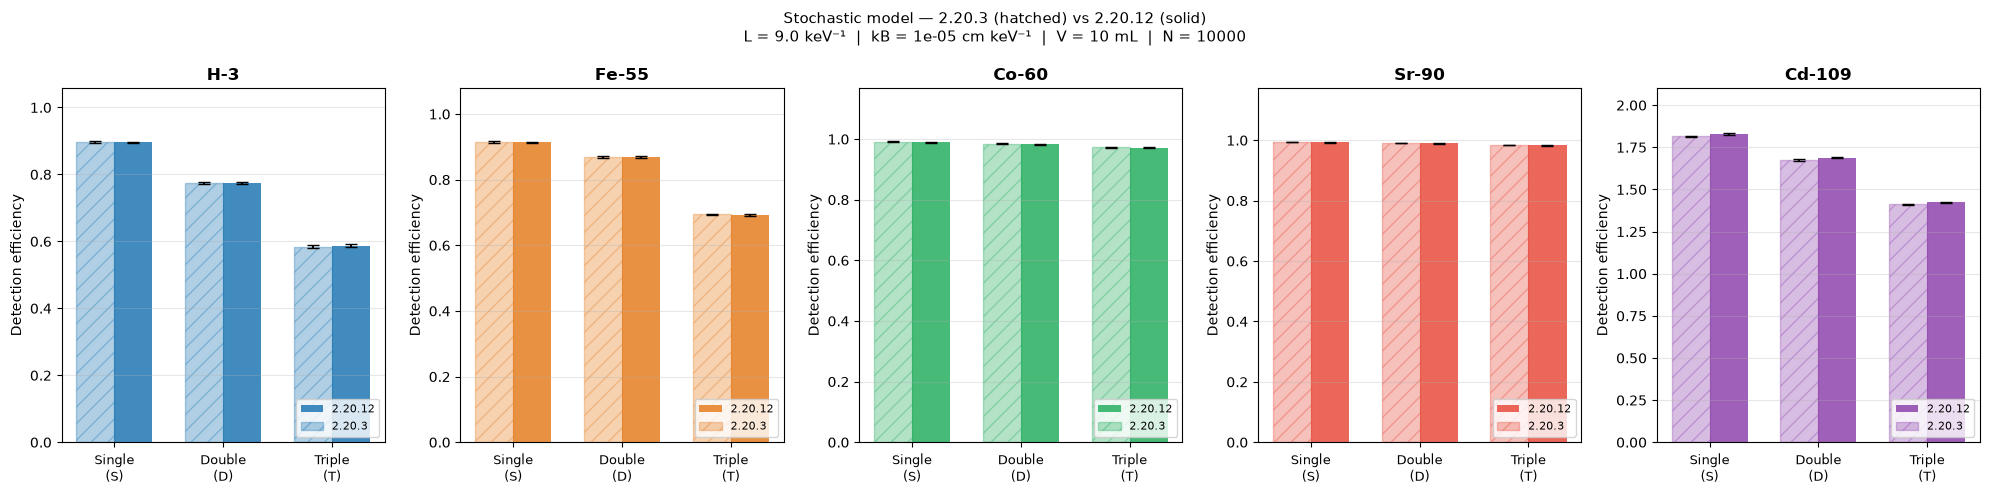

Figure saved.


In [33]:
n_nuc = len(NUCLIDES)
fig, axes = plt.subplots(1, n_nuc, figsize=(4 * n_nuc, 5))
if n_nuc == 1: axes = [axes]
fig.suptitle(
    f'Stochastic model — {VERSION_REF} (hatched) vs {VERSION_NEW} (solid)\n'
    f'L = {L} keV⁻¹  |  kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
    fontsize=11)

EFF  = ['eff_S', 'eff_D', 'eff_T']
UKEY = ['u_S',   'u_D',   'u_T'  ]
XLBL = ['Single\n(S)', 'Double\n(D)', 'Triple\n(T)']
x    = np.arange(3)
w    = 0.35

for ax, rad, col in zip(axes, NUCLIDES, COLORS):
    r_ref = stoch_ref.get(rad, {})
    r_new = stoch_new.get(rad, {})

    # new version — solid bars
    if 'eff_S' in r_new:
        ax.bar(x + w/2, [r_new[k] for k in EFF], w,
               yerr=[r_new[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label=VERSION_NEW)

    # reference version — hatched bars or error box
    if 'eff_S' in r_ref:
        ax.bar(x - w/2, [r_ref[k] for k in EFF], w,
               yerr=[r_ref[k] for k in UKEY], capsize=4,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label=VERSION_REF)
    else:
        err_txt = r_ref.get('error', r_ref.get('_parse_error', '?'))
        ax.text(0.5, 0.5,
                f'v{VERSION_REF}\n{err_txt}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red',
                bbox=dict(boxstyle='round', fc='#fff0f0', ec='red', lw=1.5))
        ax.bar(x - w/2, [0, 0, 0], w, color=col, alpha=0.15, hatch='//',
               edgecolor=col, label=f'{VERSION_REF} — ERROR')

    ax.set_title(rad, fontsize=12, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
    ax.set_ylabel('Detection efficiency')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ymax = max((max(r_new.get(k, 0) for k in EFF) if 'eff_S' in r_new else 1), 0.05)
    ax.set_ylim(0, min(ymax * 1.18, 2.1))

plt.tight_layout()
plt.savefig(f'validation_stochastic_{VERSION_REF}_vs_{VERSION_NEW}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6. Analytical vs Stochastic — new version only

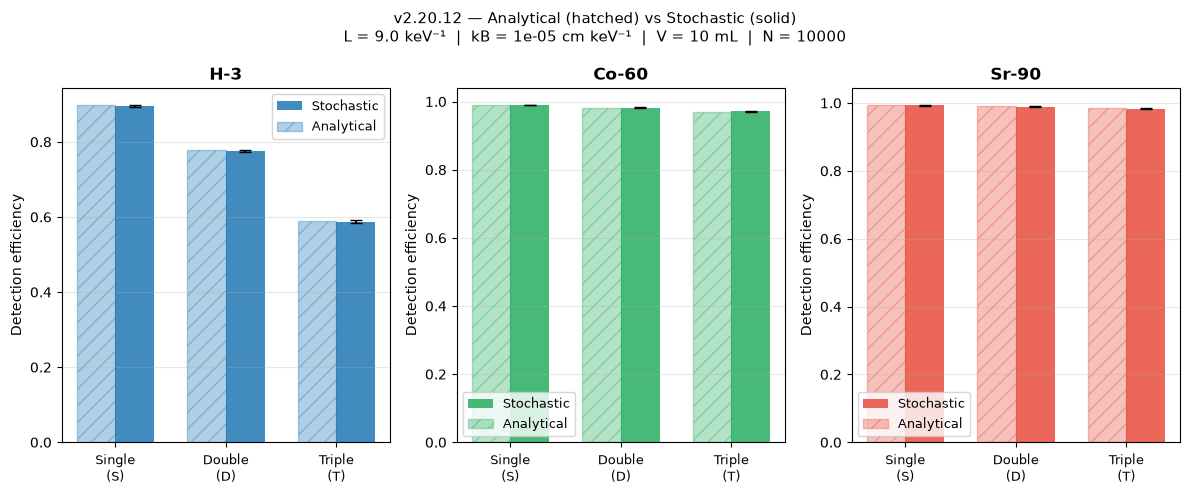

Figure saved.


In [34]:
# Only nuclides where both models are available (β emitters or have a β spectrum)
both_models = [r for r in NUCLIDES if 'eff_S' in ana_new.get(r, {}) and 'eff_S' in stoch_new.get(r, {})]

if not both_models:
    print('No nuclide with both analytical and stochastic results.')
else:
    n = len(both_models)
    fig2, axes2 = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes2 = [axes2]
    fig2.suptitle(f'v{VERSION_NEW} — Analytical (hatched) vs Stochastic (solid)\n'
                  f'L = {L} keV⁻¹  |  kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
                  fontsize=11)

    for ax, rad in zip(axes2, both_models):
        col = COLORS[NUCLIDES.index(rad)]
        r_s = stoch_new[rad]
        r_a = ana_new[rad]

        ax.bar(x + w/2, [r_s[k] for k in EFF], w,
               yerr=[r_s[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label='Stochastic')
        ax.bar(x - w/2, [r_a[k] for k in EFF], w,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label='Analytical')

        ax.set_title(rad, fontsize=12, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
        ax.set_ylabel('Detection efficiency')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'validation_analytical_vs_stochastic_{VERSION_NEW}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved.')

## 6b. Analytical vs Stochastic — reference version

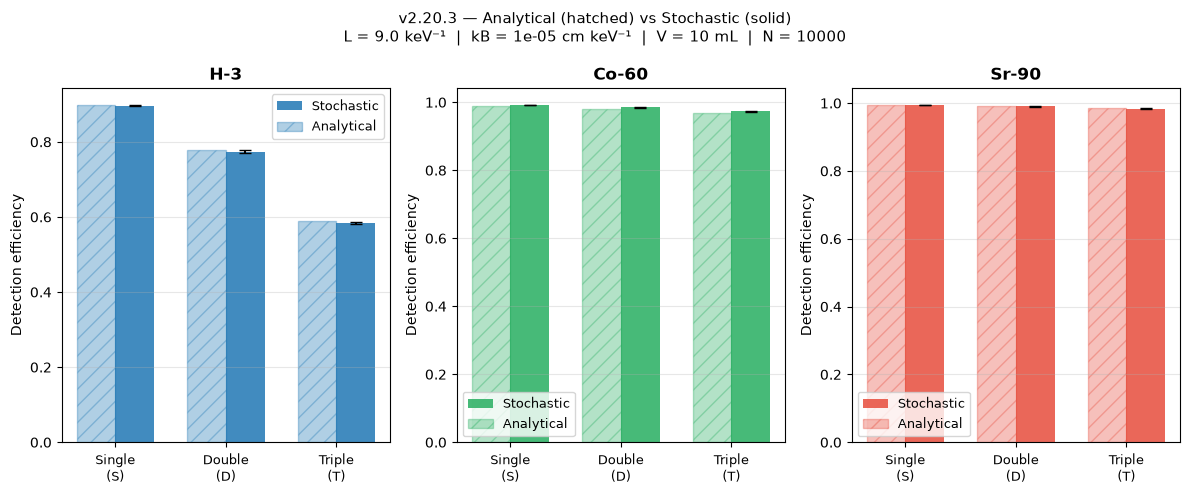

Figure saved — v2.20.3.
  Not shown (no result in ≥1 model for v2.20.3): ['Fe-55', 'Cd-109']


In [35]:
both_models_ref = [r for r in NUCLIDES
                   if 'eff_S' in ana_ref.get(r, {}) and 'eff_S' in stoch_ref.get(r, {})]

if not both_models_ref:
    print(f'No nuclide with both analytical and stochastic results for v{VERSION_REF}.')
else:
    n = len(both_models_ref)
    fig3, axes3 = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes3 = [axes3]
    fig3.suptitle(f'v{VERSION_REF} — Analytical (hatched) vs Stochastic (solid)\n'
                  f'L = {L} keV⁻¹  |  kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
                  fontsize=11)

    for ax, rad in zip(axes3, both_models_ref):
        col = COLORS[NUCLIDES.index(rad)]
        r_s = stoch_ref[rad]
        r_a = ana_ref[rad]

        ax.bar(x + w/2, [r_s[k] for k in EFF], w,
               yerr=[r_s[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label='Stochastic')
        ax.bar(x - w/2, [r_a[k] for k in EFF], w,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label='Analytical')

        ax.set_title(rad, fontsize=12, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
        ax.set_ylabel('Detection efficiency')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'validation_analytical_vs_stochastic_{VERSION_REF}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved — v{VERSION_REF}.')
    if len(both_models_ref) < len(NUCLIDES):
        missing = [r for r in NUCLIDES if r not in both_models_ref]
        print(f'  Not shown (no result in ≥1 model for v{VERSION_REF}): {missing}')

## 7. Validation summary

In [36]:
print(f'\n══════════════════════════════════════════════════════════════════')
print(f'  FUNCTIONAL VALIDATION SUMMARY')
print(f'  Reference : {VERSION_REF}   New : {VERSION_NEW}')
print(f'  L={L} keV⁻¹  kB={kB} cm keV⁻¹  V={V} mL  N={N}')
print(f'══════════════════════════════════════════════════════════════════')
print(f'{"Nuclide":<10}  {"Analytical":^24}  {"Stochastic":^24}')
print(f'{"":10}  {VERSION_REF:^11} {VERSION_NEW:^11}  {VERSION_REF:^11} {VERSION_NEW:^11}')
print(f'──────────────────────────────────────────────────────────────────')

all_pass = True
for rad in NUCLIDES:
    sym_a_ref, _ = status(ana_ref.get(rad, {}))
    sym_a_new, _ = status(ana_new.get(rad, {}))
    sym_s_ref, _ = status(stoch_ref.get(rad, {}))
    sym_s_new, _ = status(stoch_new.get(rad, {}))
    print(f'{rad:<10}  {sym_a_ref:^11} {sym_a_new:^11}  {sym_s_ref:^11} {sym_s_new:^11}')
    if sym_s_new == '✗':
        all_pass = False

print(f'══════════════════════════════════════════════════════════════════')
print(f'  ✓ = OK   ✗ = error   — = N/A (no β spectrum for this model)')
verdict = '  ✅ PASSED' if all_pass else '  ❌ FAILED — see ✗ entries above'
print(f'  Stochastic {VERSION_NEW}: {verdict}')
print(f'══════════════════════════════════════════════════════════════════')


══════════════════════════════════════════════════════════════════
  FUNCTIONAL VALIDATION SUMMARY
  Reference : 2.20.3   New : 2.20.12
  L=9.0 keV⁻¹  kB=1e-05 cm keV⁻¹  V=10 mL  N=10000
══════════════════════════════════════════════════════════════════
Nuclide            Analytical                Stochastic       
              2.20.3      2.20.12      2.20.3      2.20.12  
──────────────────────────────────────────────────────────────────
H-3              ✓           ✓            ✓           ✓     
Fe-55            ✗           ✗            ✓           ✓     
Co-60            ✓           ✓            ✓           ✓     
Sr-90            ✓           ✓            ✓           ✓     
Cd-109           ✗           ✗            ✓           ✓     
══════════════════════════════════════════════════════════════════
  ✓ = OK   ✗ = error   — = N/A (no β spectrum for this model)
  Stochastic 2.20.12:   ✅ PASSED
══════════════════════════════════════════════════════════════════
